# Clustering Experiments (Task 1)


## 1. Import project modules

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from src.utils.config import RANDOM_SEED, K_SEARCH_VALUES, RESULTS_DIR, DIAGNOSTICS_DIR, MIN_CLUSTER_SIZE
from src.utils.data_loader import load_train_data
from src.preprocessing.eda_analysis import (
    build_phase1_clustering_summary,
    summarize_phase1_findings,
    sample_households_by_regime,
)
from src.preprocessing.data_cleaning import z_normalize_rows

In [2]:
import matplotlib as mpl

# Global plot styling for the notebook
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#BBBBBB",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

METHOD_TITLES = {
    "feature_ward": "Feature + Ward",
    "kshape": "k-Shape",
}

CANDIDATE_TITLES = {
    "feature_ward_k2": "Feature + Ward (k=2)",
    "feature_ward_k4": "Feature + Ward (k=4)",
    "kshape_k3": "k-Shape (k=3)",
}

## 2. Load 2023 data

In [3]:
train_data = load_train_data()
print("2023 data shape:", train_data.shape)
train_data.head()

2023 data shape: (17547, 365)


,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-14,2023-01-15,2023-01-16,2023-01-17,2023-01-18,2023-01-19,2023-01-20,2023-01-21,2023-01-22,2023-01-23,2023-01-24,2023-01-25,2023-01-26,2023-01-27,2023-01-28,2023-01-29,2023-01-30,2023-01-31,2023-02-01,2023-02-02,2023-02-03,2023-02-04,2023-02-05,2023-02-06,2023-02-07,2023-02-08,2023-02-09,2023-02-10,2023-02-11,2023-02-12,2023-02-13,2023-02-14,2023-02-15,2023-02-16,2023-02-17,2023-02-18,2023-02-19,2023-02-20,2023-02-21,2023-02-22,2023-02-23,2023-02-24,2023-02-25,2023-02-26,2023-02-27,2023-02-28,2023-03-01,...,2023-11-02,2023-11-03,2023-11-04,2023-11-05,2023-11-06,2023-11-07,2023-11-08,2023-11-09,2023-11-10,2023-11-11,2023-11-12,2023-11-13,2023-11-14,2023-11-15,2023-11-16,2023-11-17,2023-11-18,2023-11-19,2023-11-20,2023-11-21,2023-11-22,2023-11-23,2023-11-24,2023-11-25,2023-11-26,2023-11-27,2023-11-28,2023-11-29,2023-11-30,2023-12-01,2023-12-02,2023-12-03,2023-12-04,2023-12-05,2023-12-06,2023-12-07,2023-12-08,2023-12-09,2023-12-10,2023-12-11,2023-12-12,2023-12-13,2023-12-14,2023-12-15,2023-12-16,2023-12-17,2023-12-18,2023-12-19,2023-12-20,2023-12-21,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,14.919,15.857,9.548,17.012,10.418,12.334,7.831,13.218,16.940,10.218,13.284,16.705,11.144,10.584,12.147,10.227,13.493,8.332,12.385,11.630,10.220,13.085,10.575,12.303,7.309,12.538,12.556,9.779,11.061,10.558,17.042,7.561,6.555,10.233,8.313,13.107,13.444,10.206,6.631,7.106,16.134,15.093,12.810,17.781,13.160,16.116,15.069,14.693,10.876,11.172,9.697,...,6.790,10.572,9.262,13.251,7.947,11.880,8.406,10.264,9.745,12.438,13.437,10.375,12.300,8.589,11.631,7.021,13.090,14.158,11.762,14.625,10.807,12.843,10.075,11.432,12.506,11.898,10.610,10.646,12.792,8.9390,8.0310,17.603,10.668,13.352,13.538,10.678,11.606,9.126,10.252,12.812,15.689,18.821,10.496,11.744,7.239,12.406,10.399,8.770,10.815,15.4040,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,36.268,27.777,20.105,33.540,23.782,40.718,36.632,19.057,19.269,42.033,22.015,77.582,74.349,66.155,63.771,63.654,67.846,66.374,81.248,66.523,55.536,64.469,48.979,51.721,61.247,28.666,14.344,15.189,16.333,16.317,37.187,62.350,52.038,43.545,45.985,43.998,37.220,25.280,34.503,21.953,31.780,15.589,14.982,11.713,13.852,11.568,14.035,31.517,33.955,26.670,27.101,...,9.145,30.610,12.702,12.921,10.513,20.233,14.337,15.512,18.097,24.882,14.161,19.491,10.518,19.996,11.812,20.105,37.555,29.707,14.230,34.439,39.691,26.815,36.772,45.102,37.179,29.940,33.085,35.579,45.483,57.7780,70.3850,65.881,58.904,49.808,69.945,46.836,46.264,53.775,42.479,37.160,25.821,39.058,31.575,37.803,33.341,37.649,34.798,15.538,33.862,39.0540,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,8.156,9.085,10.667,9.193,14.340,8.977,9.829,9.775,8.612,9.949,9.755,7.560,8.457,7.561,7.697,14.485,18.173,8.182,13.784,8.113,7.636,7.320,14.064,9.123,10.457,8.380,10.561,7.867,6.479,12.770,8.469,5.658,12.384,8.314,9.165,11.003,9.296,8.075,8.166,12.186,13.906,13.462,9.527,12.835,8.707,8.539,17.696,11.860,9.873,9.343,7.663,...,0.945,7.413,3.626,9.382,3.910,2.018,3.441,1.655,0.158,10.814,3.522,3.959,3.975,6.109,5.874,3.794,0.535,14.302,6.084,6.544,7.823,5.062,3.551,9.936,16.217,7.629,15.145,17.608,10.005,12.3825,12.3825,10.850,13.260,10.451,15.217,9.834,12.589,14.536,12.495,6.489,1.036,8.501,9.968,6.502,8.410,11.115,4.556,1.249,4.130,16.9350,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,6.134,9.488,7.986,9.001,9.995,17

## 3. Phase 1 diagnostics

In [4]:
phase1_summary = summarize_phase1_findings(train_data)
phase1_summary

{'n_households': 17547,
 'n_degenerate': 338,
 'degenerate_breakdown_exclusive': {'all_zero': 154,
  'near_constant': 96,
  'zero_heavy': 88},
 'mean_household_consumption_median': 6.776293150684931,
 'mean_household_consumption_iqr': [3.869212328767124, 11.35613287671233],
 'weekly_acf_median': 0.31237500306698407,
 'peak_month_mode': np.int64(12),
 'n_all_zero': 154,
 'n_near_constant': 96,
 'n_zero_heavy': 88}

In [5]:
diagnostics = build_phase1_clustering_summary(train_data)
diagnostics.head()

,mean,median,std,min,max,range,q25,q75,cv,skew,kurtosis,zero_days,zero_pct,autocorr_lag_1,autocorr_lag_7,autocorr_lag_30,monthly_profile_std,trend_slope_normalized,winter_mean,summer_mean,winter_summer_contrast,peak_month_eda,all_zero_flag,near_constant_flag,zero_heavy_flag,regime_label,degenerate_flag
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
22,11.857921,11.432,3.978609,1.928,25.944,24.016,9.262,13.955,0.335523,0.429918,0.657654,0,0.0,0.589803,0.431239,0.210211,2.754714,-0.002392,11.627233,12.602130,-0.040236,6,False,False,False,regular,False
42,14.054819,3.610,18.981447,0.059,81.248,81.189,0.116,23.776,1.350529,1.367075,1.027541,0,0.0,0.907323,0.769474,0.518330,17.028304,-0.001197,39.575456,0.207587,0.989564,1,False,False,False,regular,False
56,5.609575,5.739,5.217587,0.062,23.488,23.426,0.212,9.343,0.930122,0.494557,-0.788557,0,0.0,0.783508,0.646670,0.354682,4.259686,-0.003180,9.910100,0.896815,0.834029,2,False,False,False,regular,False
58,9.320200,8.057,5.298971,1.958,39.773,37.815,6.005,10.757,0.568547,1.923011,4.959361,0,0.0,0.693289,0.620724,0.304283,4.085130,0.003210,12.623678,6.790728,0.300444,12,False,False,False,regular,False
64,2.438655,2.422,0.515581,0.137,4.400,4.263,2.167,2.692,0.211420,0.168067,2.390242,0,0.0,0.110696,0.191981,-0.041984,0.195540,-0.000428,2.490733,2.257554,0.049108,3,False,False,False,regular,False


In [6]:
summary_table = pd.DataFrame({
    "metric": [
        "n_households",
        "n_all_zero",
        "n_near_constant",
        "n_zero_heavy",
        "n_degenerate",
    ],
    "value": [
        phase1_summary["n_households"],
        phase1_summary["n_all_zero"],
        phase1_summary["n_near_constant"],
        phase1_summary["n_zero_heavy"],
        phase1_summary["n_degenerate"],
    ]
})

summary_table.loc[len(summary_table)] = [
    "degenerate_pct",
    round(100 * phase1_summary["n_degenerate"] / phase1_summary["n_households"], 2),
]
summary_table

,metric,value
0,n_households,17547.00
1,n_all_zero,154.00
2,n_near_constant,96.00
3,n_zero_heavy,88.00
4,n_degenerate,338.00
5,degenerate_pct,1.93


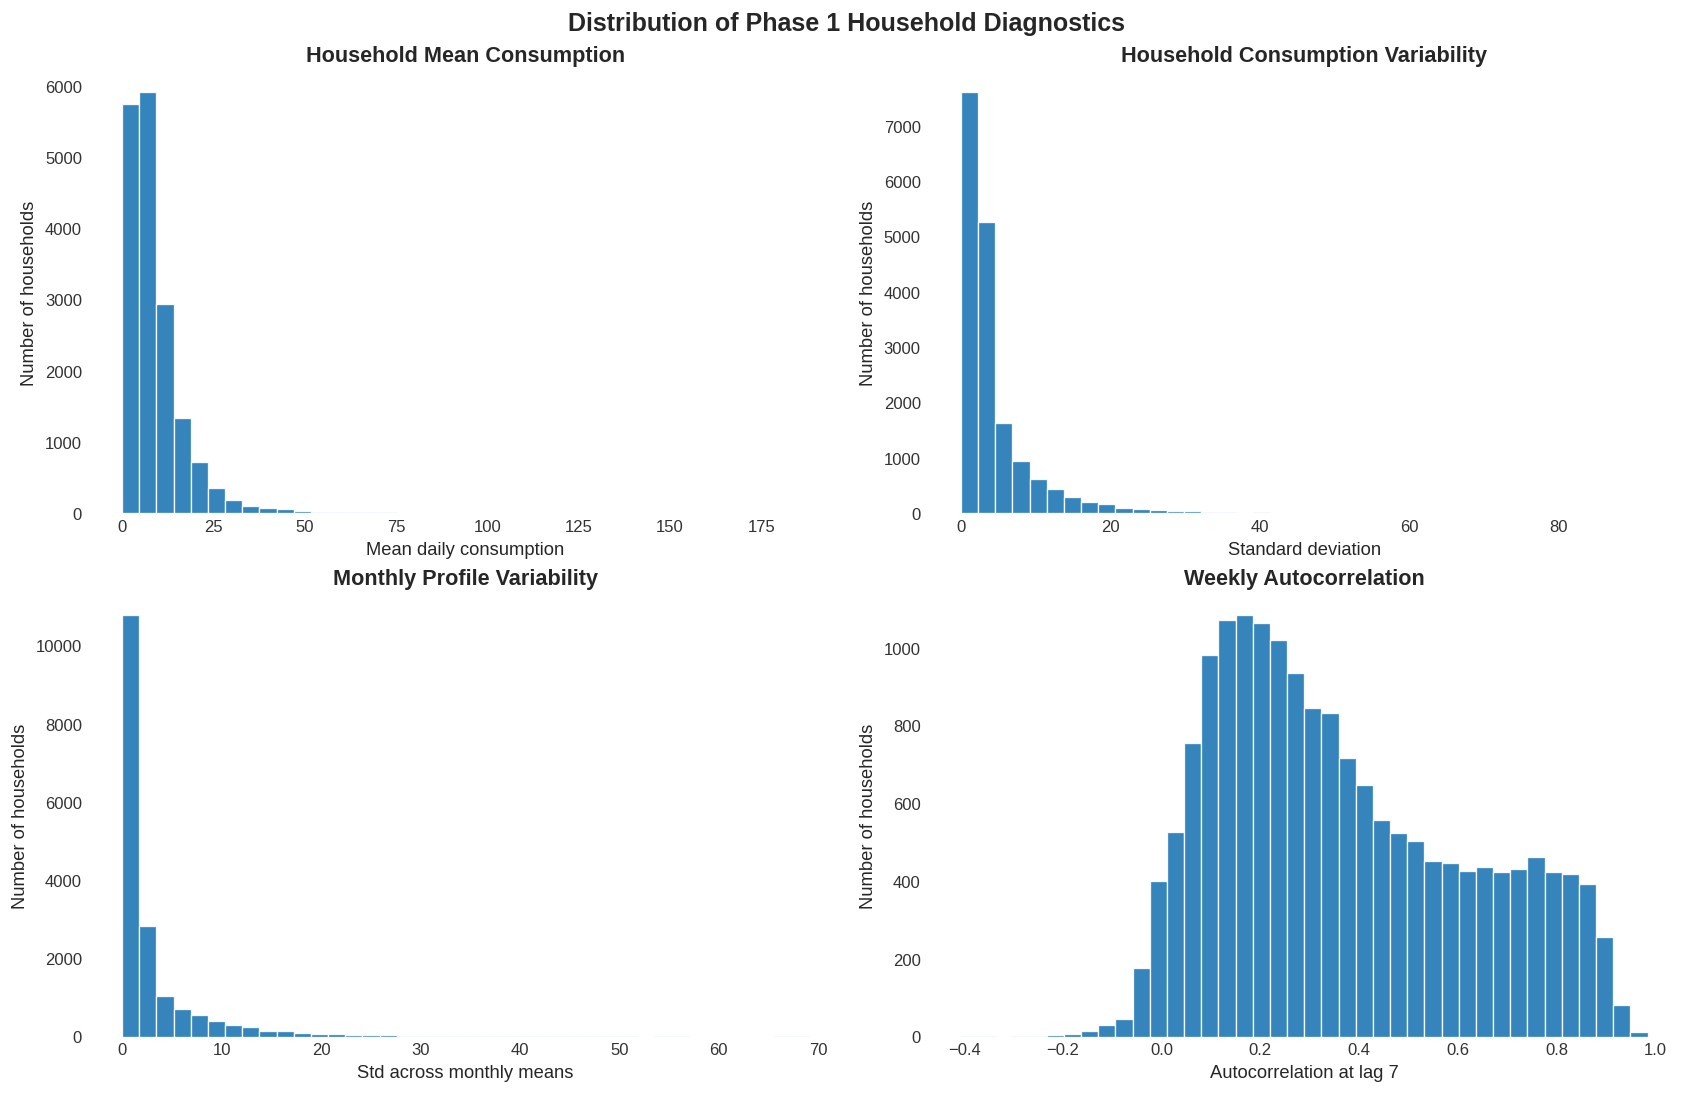

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

hist_specs = [
    ("mean", "Household Mean Consumption", "Mean daily consumption"),
    ("std", "Household Consumption Variability", "Standard deviation"),
    ("monthly_profile_std", "Monthly Profile Variability", "Std across monthly means"),
    ("autocorr_lag_7", "Weekly Autocorrelation", "Autocorrelation at lag 7"),
]

for ax, (col, title, xlabel) in zip(axes.flat, hist_specs):
    ax.hist(diagnostics[col], bins=40, edgecolor="white", linewidth=0.8, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of households")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Distribution of Phase 1 Household Diagnostics", fontsize=15, fontweight="bold")
plt.show()

In [8]:
sampled_ids = sample_households_by_regime(diagnostics, n_per_group=3, random_state=RANDOM_SEED)
sampled_ids

{'all_zero': [187784, 30390, 229787],
 'near_constant': [21655, 183166, 242208],
 'zero_heavy': [165663, 300914, 228961],
 'high_mean': [154114, 240653, 38003],
 'high_weekly_structure': [152749, 113589, 56348],
 'high_annual_variation': [249585, 192828, 121725]}

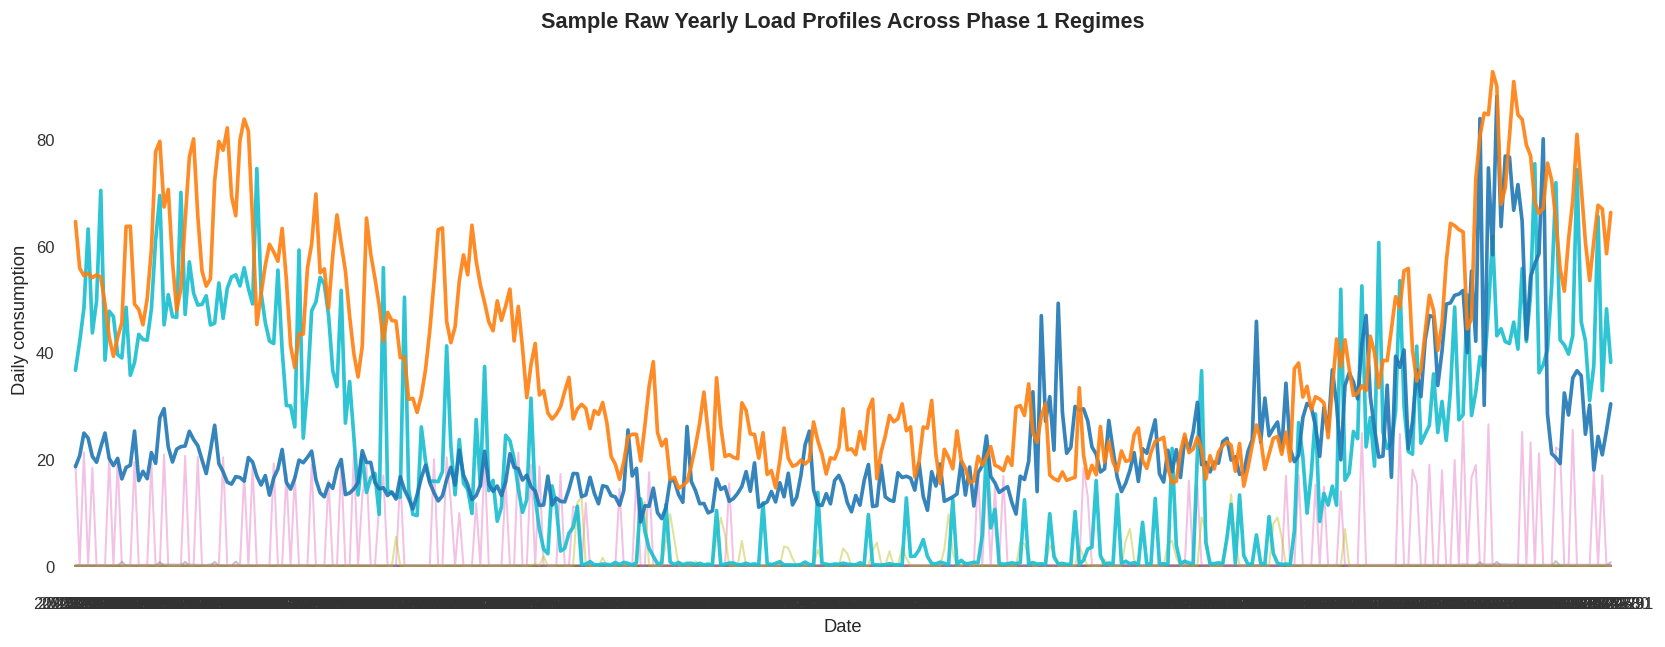

In [9]:
flat_ids = [hh for group in sampled_ids.values() for hh in group][:12]

if flat_ids:
    fig, ax = plt.subplots(figsize=(14, 5.5))
    plot_data = train_data.loc[flat_ids].T

    for i, col in enumerate(plot_data.columns):
        ax.plot(
            plot_data.index,
            plot_data[col],
            alpha=0.45 if i < len(plot_data.columns) - 3 else 0.9,
            linewidth=1.2 if i < len(plot_data.columns) - 3 else 2.2,
        )

    ax.set_title("Sample Raw Yearly Load Profiles Across Phase 1 Regimes", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily consumption")
    ax.grid(axis="y", alpha=0.25)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

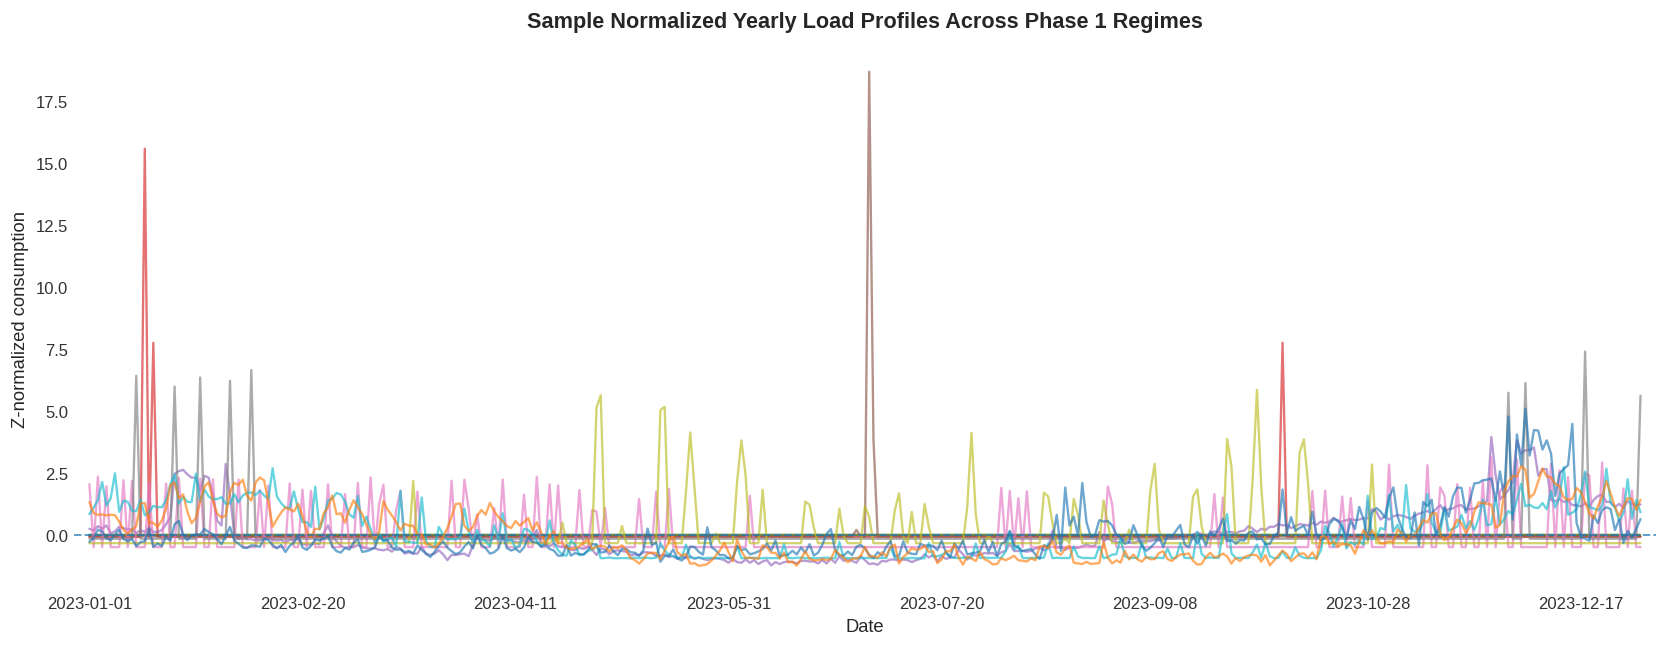

In [10]:
if flat_ids:
    norm_sample = z_normalize_rows(train_data.loc[flat_ids])
    ax = norm_sample.T.plot(
        figsize=(14, 5.5),
        legend=False,
        alpha=0.65,
        linewidth=1.4
    )
    ax.axhline(0, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_title("Sample Normalized Yearly Load Profiles Across Phase 1 Regimes", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Z-normalized consumption")
    ax.grid(axis="y", alpha=0.25)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

## 4. Search and evaluate candidate \(k\) values

This section runs each clustering method across the chosen candidate \(k\) values, evaluates the results, ranks them, and applies a structural shortlist before selecting the best candidate for each method.

In [11]:
from src.clustering.clustering_evaluation import ClusteringEvaluator
from src.clustering.cluster_reporting import ClusterReporter
from src.clustering.clustering import HouseholdClusterer

evaluator = ClusteringEvaluator()
reporter = ClusterReporter()
clusterer = HouseholdClusterer(random_seed=RANDOM_SEED)

/home/hemali/.local/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


### Feature-Ward Clustering

In [12]:
# --------------------------------------------
# 1) Primary full-data method: feature_ward
# --------------------------------------------
feature_ward_bundle = clusterer.prepare_feature_ward_input(train_data)

feature_ward_artifacts_by_k = {}
feature_ward_rows = []

for k in K_SEARCH_VALUES:
    result = clusterer.run_feature_ward_on_prepared(
        prepared_bundle=feature_ward_bundle,
        k=k,
    )
    feature_ward_artifacts_by_k[k] = result

    row = evaluator.evaluate_single_result(
        result=result,
        data_2023=train_data,
        min_cluster_size=MIN_CLUSTER_SIZE,
    )

    # Stability is only used for the primary method
    stability = evaluator.estimate_stability(
        method="feature_ward",
        data_2023=train_data,
        k=k,
    )
    row["stability_mean"] = stability.mean_score
    row["stability_std"] = stability.std_score
    row["stability_successful_runs"] = stability.successful_runs
    row["stability_failed_runs"] = stability.failed_runs

    feature_ward_rows.append(row)

feature_ward_results = pd.DataFrame(feature_ward_rows)
display(feature_ward_results)

feature_ward produced a very small cluster (min size=256) at k=6
feature_ward produced a very small cluster (min size=274) at k=6
feature_ward produced a very small cluster (min size=287) at k=6
feature_ward produced a very small cluster (min size=259) at k=6
feature_ward produced a very small cluster (min size=256) at k=7
feature_ward produced a very small cluster (min size=274) at k=7
feature_ward produced a very small cluster (min size=287) at k=7
feature_ward produced a very small cluster (min size=259) at k=7
feature_ward produced a very small cluster (min size=256) at k=8
feature_ward produced a very small cluster (min size=262) at k=8
feature_ward produced a very small cluster (min size=287) at k=8
feature_ward produced a very small cluster (min size=214) at k=8
feature_ward produced a very small cluster (min size=259) at k=8
feature_ward produced a very small cluster (min size=256) at k=9
feature_ward produced a very small cluster (min size=262) at k=9
feature_ward produced a v

,method,k,n_households_regular_clusters,n_clusters_found,smallest_cluster,largest_cluster,has_small_clusters,cluster_balance,silhouette,davies_bouldin,calinski_harabasz,cluster_mean_spread,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning,stability_mean,stability_std,stability_successful_runs,stability_failed_runs
0,feature_ward,2,17209,2,3172,14037,False,0.225974,0.314861,1.035178,6647.532362,6.353672,11.960216,0.531234,False,0.544776,0.220264,10,0
1,feature_ward,3,17209,3,3172,7684,False,0.412806,0.180146,1.957813,5225.218778,7.562839,9.054137,0.835291,False,0.470169,0.104010,10,0
2,feature_ward,4,17209,4,1967,7684,False,0.255986,0.177266,1.988609,4341.373788,7.562839,10.747730,0.703668,False,0.437956,0.092384,10,0
3,feature_ward,5,17209,5,1967,5238,False,0.375525,0.149016,1.926564,3771.332620,7.853182,9.899686,0.793276,False,0.424666,0.079909,10,0
4,feature_ward,6,17209,6,256,5238,True,0.048874,0.153295,1.843196,3300.289851,14.525495,11.235278,1.292847,False,0.419768,0.086656,10,0
5,feature_ward,7,17209,7,256,5238,True,0.048874,0.154322,1.829686,2985.461561,14.525495,12.416092,1.169893,False,0.410334,0.079196,10,0
6,feature_ward,8,17209,8,256,5238,True,0.048874,0.128420,2.091873,2739.689697,14.525495,11.542445,1.258442,False,0.416203,0.072683,10,0
7,feature_ward,9,17209,9,256,5238,True,0.048874,0.124813,2.032085,2514.889714,14.525495,12.270887,1.183736,False,0.407103,0.060760,10,0
8,feature_ward,10,17209,10,256,5238,True,0.048874,0.100449,2.113253,2343.392513,14.525495,12.542351,1.158116,False,0.386558,0.047281,10,0


### K-Shape

K-shape results are saved, so the next two cells can be skipped by loading the results from cache.

In [ ]:
# --------------------------------------------
# 2) Shape benchmark: k-Shape
# --------------------------------------------
kshape_bundle = clusterer.prepare_kshape_input(train_data)

kshape_artifacts_by_k = {}
kshape_rows = []

for k in K_SEARCH_VALUES:
    result = clusterer.run_kshape_on_prepared(
        kshape_bundle=kshape_bundle,
        k=k,
        n_init=1,
    )
    kshape_artifacts_by_k[k] = result

    row = evaluator.evaluate_single_result(
        result=result,
        data_2023=train_data,
        min_cluster_size=MIN_CLUSTER_SIZE,
    )

    # No stability for benchmarks in the final notebook run
    row["stability_mean"] = None
    row["stability_std"] = None
    row["stability_successful_runs"] = None
    row["stability_failed_runs"] = None

    kshape_rows.append(row)

kshape_results = pd.DataFrame(kshape_rows)
display(kshape_results)

In [ ]:
cache_dir = RESULTS_DIR / "clustering_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

with open(cache_dir / "kshape_artifacts_by_k.pkl", "wb") as f:
    pickle.dump(kshape_artifacts_by_k, f)

kshape_results.to_csv(cache_dir / "kshape_results.csv", index=False)

print("Saved:")
print(cache_dir / "kshape_artifacts_by_k.pkl")
print(cache_dir / "kshape_results.csv")

In [14]:
# Load and display k-Shape results from cache

cache_dir = RESULTS_DIR / "clustering_cache"

with open(cache_dir / "kshape_artifacts_by_k.pkl", "rb") as f:
    kshape_artifacts_by_k = pickle.load(f)

kshape_results = pd.read_csv(cache_dir / "kshape_results.csv")

display(kshape_results)

,method,k,n_households_regular_clusters,n_clusters_found,smallest_cluster,largest_cluster,has_small_clusters,cluster_balance,silhouette,davies_bouldin,calinski_harabasz,cluster_mean_spread,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning,stability_mean,stability_std,stability_successful_runs,stability_failed_runs
0,kshape,2,17209,2,8429,8780,False,0.960023,0.066217,3.850061,1138.252583,2.512654,9.115156,0.275657,False,NaN,NaN,NaN,NaN
1,kshape,3,17209,3,4760,7445,False,0.639355,0.034995,8.793263,406.422190,3.957285,6.216636,0.636564,False,NaN,NaN,NaN,NaN
2,kshape,4,17209,4,2850,6418,False,0.444064,0.037391,7.486001,438.212398,4.096841,7.156200,0.572488,False,NaN,NaN,NaN,NaN
3,kshape,5,17209,5,1982,5901,False,0.335875,0.030888,12.551215,308.401024,5.596201,6.199967,0.902618,False,NaN,NaN,NaN,NaN
4,kshape,6,17209,6,783,5371,False,0.145783,0.038073,7.220433,349.610522,5.150027,7.646664,0.673500,False,NaN,NaN,NaN,NaN
5,kshape,7,17209,7,690,4144,False,0.166506,0.015432,8.330204,341.230627,6.420282,8.115273,0.791136,False,NaN,NaN,NaN,NaN
6,kshape,8,17209,8,692,4645,False,0.148977,0.019542,8.525916,317.695003,6.507127,8.144341,0.798975,False,NaN,NaN,NaN,NaN
7,kshape,9,17209,9,639,3043,False,0.209990,0.002326,7.469136,305.041266,8.122231,8.969226,0.905566,False,NaN,NaN,NaN,NaN
8,kshape,10,17209,10,630,3050,False,0.206557,0.005306,8.456778,287.415272,8.712806,8.971228,0.971194,False,NaN,NaN,NaN,NaN


### Filter Results

In [15]:
ranked_results = {
    "feature_ward": evaluator.rank_k_candidates(feature_ward_results),
    "kshape": evaluator.rank_k_candidates(kshape_results),
}

for method_name, ranked_df in ranked_results.items():
    print(f"\n{'='*80}")
    print(f"RANKED RESULTS: {method_name}")
    print(f"{'='*80}")
    display(
        ranked_df[
            [
                "method",
                "k",
                "composite_score",
                "smallest_cluster",
                "largest_cluster",
                "cluster_balance",
                "silhouette",
                "davies_bouldin",
                "calinski_harabasz",
                "n_available_components",
            ]
        ]
    )


RANKED RESULTS: feature_ward


,method,k,composite_score,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz,n_available_components
0,feature_ward,2,0.897326,3172,14037,0.225974,0.314861,1.035178,6647.532362,5
1,feature_ward,3,0.542777,3172,7684,0.412806,0.180146,1.957813,5225.218778,5
2,feature_ward,5,0.373972,1967,5238,0.375525,0.149016,1.926564,3771.332620,5
3,feature_ward,4,0.366408,1967,7684,0.255986,0.177266,1.988609,4341.373788,5
4,feature_ward,6,-0.314161,256,5238,0.048874,0.153295,1.843196,3300.289851,5
5,feature_ward,7,-0.337252,256,5238,0.048874,0.154322,1.829686,2985.461561,5
6,feature_ward,8,-0.414054,256,5238,0.048874,0.128420,2.091873,2739.689697,5
7,feature_ward,9,-0.428276,256,5238,0.048874,0.124813,2.032085,2514.889714,5
8,feature_ward,10,-0.500000,256,5238,0.048874,0.100449,2.113253,2343.392513,5



RANKED RESULTS: kshape


,method,k,composite_score,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz,n_available_components
0,kshape,2,1.000000,8429,8780,0.960023,0.066217,3.850061,1138.252583,4
1,kshape,3,0.422315,4760,7445,0.639355,0.034995,8.793263,406.422190,4
2,kshape,4,0.418631,2850,6418,0.444064,0.037391,7.486001,438.212398,4
3,kshape,6,0.311314,783,5371,0.145783,0.038073,7.220433,349.610522,4
4,kshape,7,0.194736,690,4144,0.166506,0.015432,8.330204,341.230627,4
5,kshape,8,0.192896,692,4645,0.148977,0.019542,8.525916,317.695003,4
6,kshape,5,0.176291,1982,5901,0.335875,0.030888,12.551215,308.401024,4
7,kshape,9,0.170910,639,3043,0.209990,0.002326,7.469136,305.041266,4
8,kshape,10,0.147963,630,3050,0.206557,0.005306,8.456778,287.415272,4


In [16]:
SHORTLIST_RULES = {
    "feature_ward": {"min_cluster_size": MIN_CLUSTER_SIZE, "min_balance": 0.25},
    "kshape": {"min_cluster_size": MIN_CLUSTER_SIZE, "min_balance": 0.25},
}

reasonable_results = {
    method_name: evaluator.shortlist_reasonable_k(
        ranked_results[method_name],
        min_cluster_size=rules["min_cluster_size"],
        min_balance=rules["min_balance"],
    )
    for method_name, rules in SHORTLIST_RULES.items()
}

for method_name, shortlist_df in reasonable_results.items():
    print(f"\n{'='*80}")
    print(f"REASONABLE K CANDIDATES: {method_name}")
    print(f"{'='*80}")
    if shortlist_df.empty:
        print("No candidates passed the structural filter.")
    else:
        display(
            shortlist_df[
                [
                    "method",
                    "k",
                    "composite_score",
                    "smallest_cluster",
                    "largest_cluster",
                    "cluster_balance",
                    "silhouette",
                    "davies_bouldin",
                    "calinski_harabasz",
                ]
            ]
        )


REASONABLE K CANDIDATES: feature_ward


,method,k,composite_score,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz
0,feature_ward,3,0.542777,3172,7684,0.412806,0.180146,1.957813,5225.218778
1,feature_ward,5,0.373972,1967,5238,0.375525,0.149016,1.926564,3771.332620
2,feature_ward,4,0.366408,1967,7684,0.255986,0.177266,1.988609,4341.373788



REASONABLE K CANDIDATES: kshape


,method,k,composite_score,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz
0,kshape,2,1.000000,8429,8780,0.960023,0.066217,3.850061,1138.252583
1,kshape,3,0.422315,4760,7445,0.639355,0.034995,8.793263,406.422190
2,kshape,4,0.418631,2850,6418,0.444064,0.037391,7.486001,438.212398
3,kshape,5,0.176291,1982,5901,0.335875,0.030888,12.551215,308.401024


In [17]:
selected_k = {}

for method_name, shortlist_df in reasonable_results.items():
    print(f"\nBest {method_name} candidate:")

    if shortlist_df.empty:
        print("No candidate passed the structural filter. Do not finalize this method.")
        continue

    best = evaluator.select_best_k(shortlist_df)
    selected_k[method_name] = best
    print(best)


Best feature_ward candidate:
{'selected_k': 3, 'method': 'feature_ward', 'composite_score': 0.5427766244680929, 'selection_row': {'method': 'feature_ward', 'k': 3, 'n_households_regular_clusters': 17209, 'n_clusters_found': 3, 'smallest_cluster': 3172, 'largest_cluster': 7684, 'has_small_clusters': False, 'cluster_balance': 0.41280583029672047, 'silhouette': 0.18014597972820837, 'davies_bouldin': 1.9578133513354228, 'calinski_harabasz': 5225.218778137387, 'cluster_mean_spread': 7.562838508421792, 'normalized_shape_separation': 9.054137126472902, 'level_to_shape_ratio': 0.8352908253419749, 'level_dominance_warning': False, 'stability_mean': 0.47016862917164115, 'stability_std': 0.10400996688341209, 'stability_successful_runs': 10, 'stability_failed_runs': 0, 'score_silhouette': 0.3717014370462175, 'score_davies_bouldin': 0.14418243211978765, 'score_calinski_harabasz': 0.6695475439922042, 'score_balance': 1.0, 'score_stability': 0.528451709182255, 'size_penalty': 0.0, 'singleton_penalty

## 5. Compare the best candidate from each method

This section gathers the selected best \(k\) result for each clustering method from the cached first-pass runs.

The goal here is to compare the selected candidates directly using:
- cluster-size balance
- monthly and weekly profile structure
- normalized profile shape
- level-vs-shape meaningfulness diagnostics

This provides a compact cross-method comparison before finalizing the primary clustering solution.

In [18]:
best_results = {}

if "feature_ward" in selected_k:
    best_results["feature_ward"] = feature_ward_artifacts_by_k[
        selected_k["feature_ward"]["selected_k"]
    ]

if "kshape" in selected_k:
    best_results["kshape"] = kshape_artifacts_by_k[
        selected_k["kshape"]["selected_k"]
    ]

best_method_summary_rows = []

for method_name, result in best_results.items():
    diag = reporter.cluster_meaningfulness_diagnostics(train_data, result.labels)
    sizes = reporter.cluster_size_summary(result)

    best_method_summary_rows.append({
        "method": method_name,
        "k": result.k,
        "n_clusters": int(sizes.shape[0]),
        "smallest_cluster": int(sizes["n_households"].min()) if not sizes.empty else None,
        "largest_cluster": int(sizes["n_households"].max()) if not sizes.empty else None,
        "cluster_balance": result.metrics.get("cluster_balance"),
        "silhouette": result.metrics.get("silhouette"),
        "level_to_shape_ratio": diag["level_to_shape_ratio"],
        "level_dominance_warning": diag["level_dominance_warning"],
    })

best_method_summary = pd.DataFrame(best_method_summary_rows)
display(best_method_summary)

,method,k,n_clusters,smallest_cluster,largest_cluster,cluster_balance,silhouette,level_to_shape_ratio,level_dominance_warning
0,feature_ward,3,3,3172,7684,0.412806,0.180146,0.835291,False
1,kshape,2,2,8429,8780,0.960023,0.066217,0.275657,False


### Cluster-size comparison for the selected best candidates

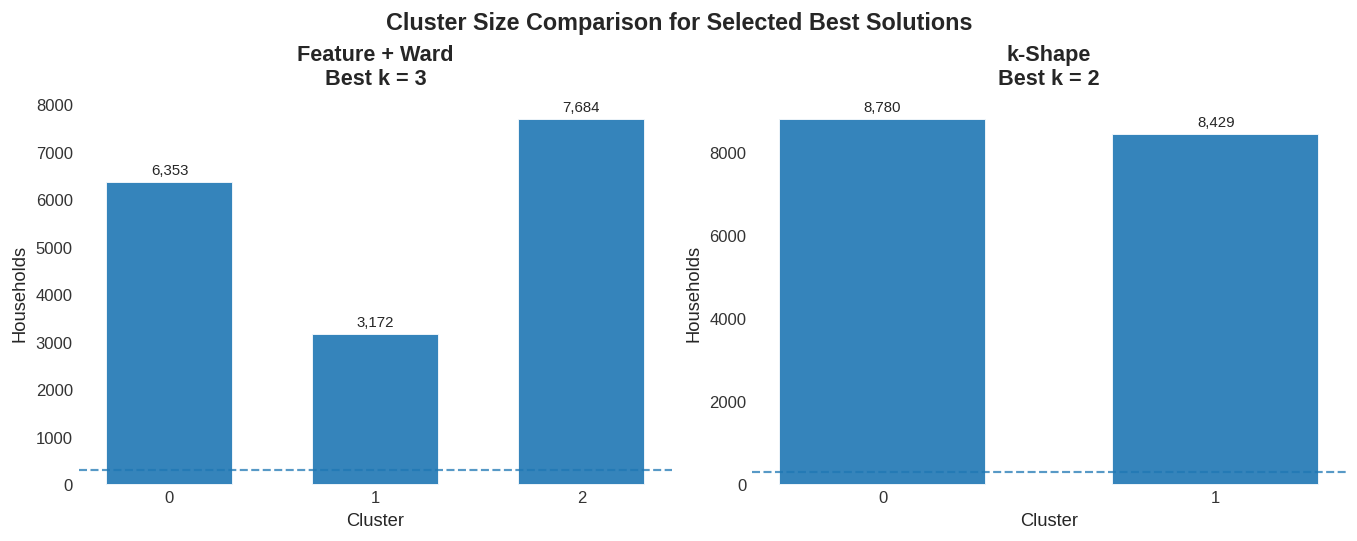

In [19]:
fig, axes = plt.subplots(
    1,
    len(best_results),
    figsize=(5.6 * len(best_results), 4.4),
    constrained_layout=True,
)

if len(best_results) == 1:
    axes = [axes]

for ax, (method_name, result) in zip(axes, best_results.items()):
    sizes = reporter.cluster_size_summary(result).copy()
    sizes["cluster"] = sizes["cluster"].astype(str)

    bars = ax.bar(
        sizes["cluster"],
        sizes["n_households"],
        width=0.62,
        alpha=0.9,
        edgecolor="white",
        linewidth=1.2,
    )

    ax.axhline(
        MIN_CLUSTER_SIZE,
        linestyle="--",
        linewidth=1.3,
        alpha=0.75,
    )

    ax.bar_label(
        bars,
        labels=[f"{v:,}" for v in sizes["n_households"]],
        padding=3,
        fontsize=9,
    )

    ax.set_title(f"{METHOD_TITLES.get(method_name, method_name)}\nBest k = {result.k}", pad=10)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Households")
    ax.grid(axis="y", alpha=0.22)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Cluster Size Comparison for Selected Best Solutions",
    fontsize=14,
    fontweight="bold",
)
plt.show()

In [20]:
for method_name, result in best_results.items():
    print(f"\n{'='*80}")
    print(f"{METHOD_TITLES.get(method_name, method_name)} | best candidate inspection")
    print(f"{'='*80}")

    print("\nCluster sizes:")
    display(reporter.cluster_size_summary(result))

    print("\nMeaningfulness diagnostics:")
    display(pd.DataFrame([reporter.cluster_meaningfulness_diagnostics(train_data, result.labels)]))


Feature + Ward | best candidate inspection

Cluster sizes:


,cluster,n_households,pct_households
0,0,6353,36.916730
1,1,3172,18.432216
2,2,7684,44.651055



Meaningfulness diagnostics:


,n_valid_clusters,cluster_mean_spread,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning
0,3,7.562839,9.054137,0.835291,False



k-Shape | best candidate inspection

Cluster sizes:


,cluster,n_households,pct_households
0,0,8780,51.019815
1,1,8429,48.980185



Meaningfulness diagnostics:


,n_valid_clusters,cluster_mean_spread,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning
0,2,2.512654,9.115156,0.275657,False


### Visual comparison of the selected best candidates

The following plots compare the selected best result from each method using complementary views:

- monthly mean cluster profiles for seasonality
- normalized mean daily profiles for shape comparison independent of scale

Together, these plots help show whether the methods are finding genuinely different temporal structures or mainly separating households by consumption level.

#### Monthly cluster profiles for the best candidate of each method

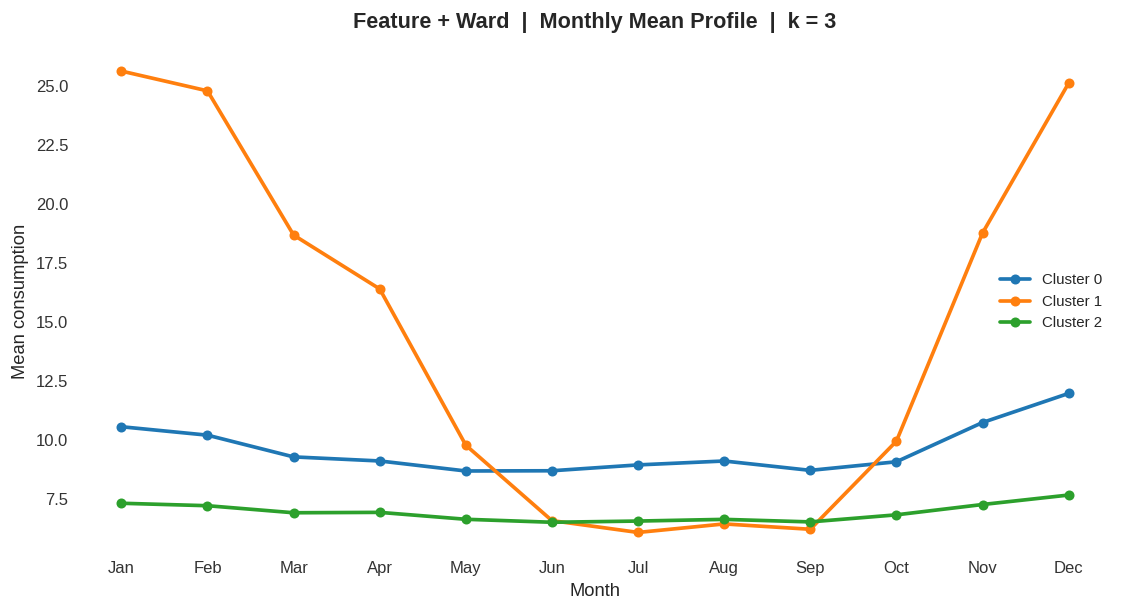

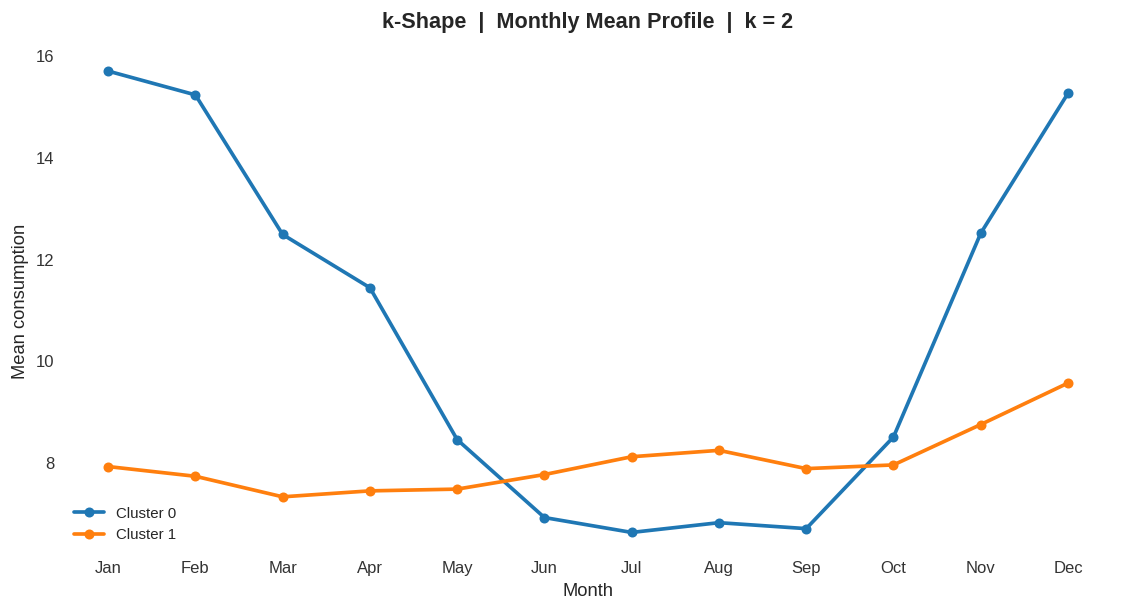

In [21]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for method_name, result in best_results.items():
    monthly_profiles = reporter.mean_monthly_profile_by_cluster(train_data, result.labels)

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    for cluster_id in monthly_profiles.index:
        ax.plot(
            range(1, len(monthly_profiles.columns) + 1),
            monthly_profiles.loc[cluster_id].values,
            marker="o",
            linewidth=2.2,
            label=f"Cluster {cluster_id}",
        )

    ax.set_title(f"{METHOD_TITLES.get(method_name, method_name)}  |  Monthly Mean Profile  |  k = {result.k}", pad=12)
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean consumption")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=2 if len(monthly_profiles.index) > 4 else 1)
    plt.tight_layout()
    plt.show()

#### Normalized mean daily profiles for the best candidate of each method

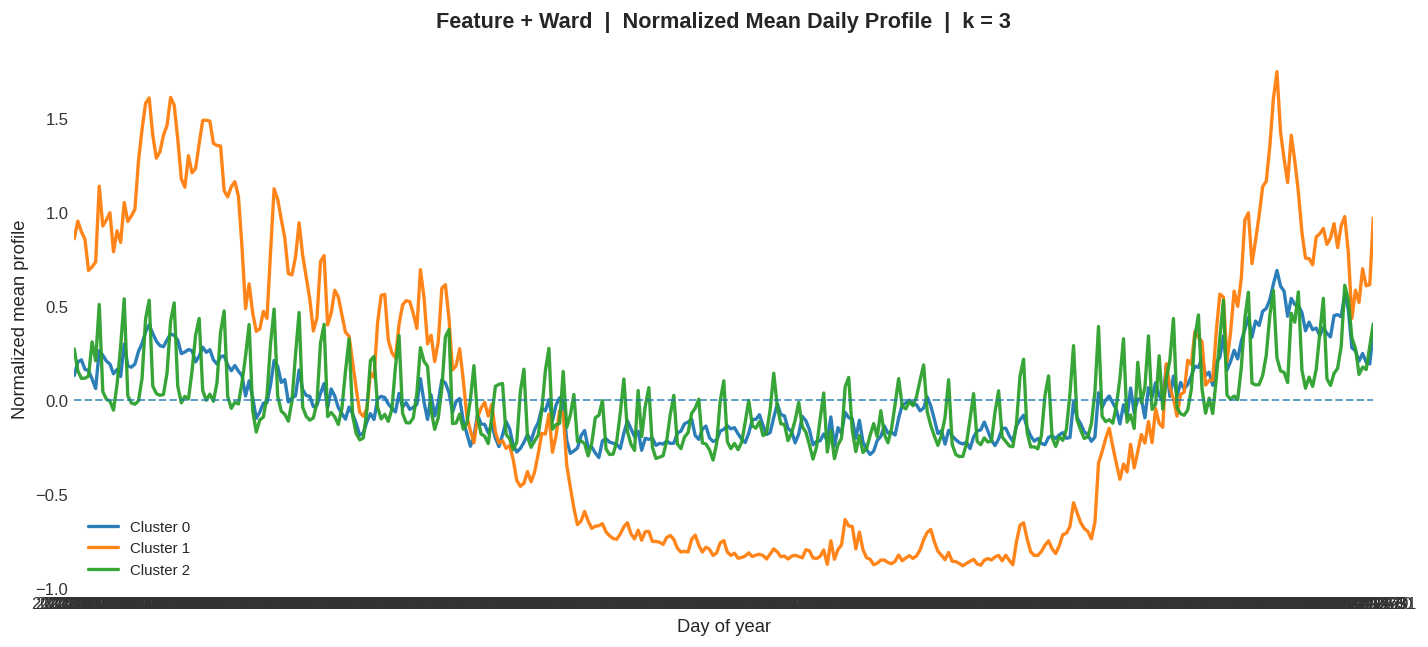

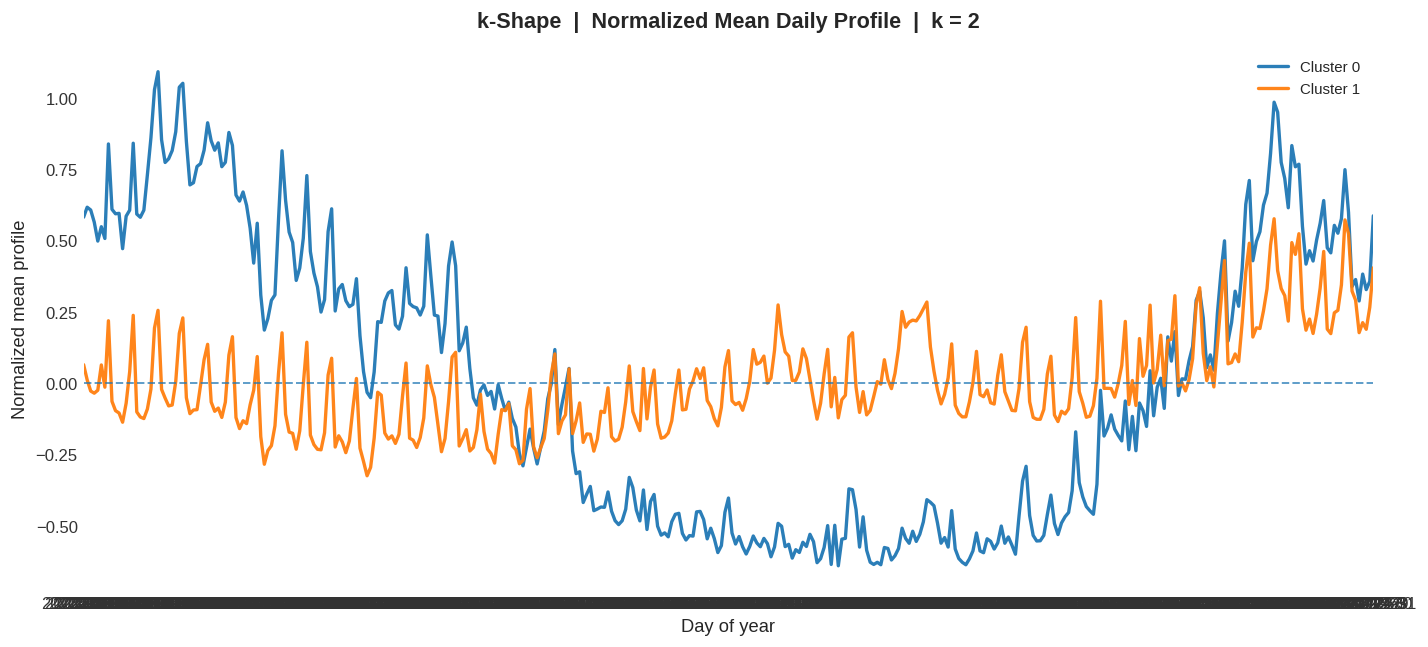

In [22]:
for method_name, result in best_results.items():
    norm_profiles = reporter.mean_normalized_profile_by_cluster(train_data, result.labels)

    fig, ax = plt.subplots(figsize=(12, 5.5))
    for cluster_id in norm_profiles.index:
        ax.plot(
            norm_profiles.columns,
            norm_profiles.loc[cluster_id],
            label=f"Cluster {cluster_id}",
            alpha=0.95,
            linewidth=2.0,
        )

    ax.axhline(0, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_title(f"{METHOD_TITLES.get(method_name, method_name)}  |  Normalized Mean Daily Profile  |  k = {result.k}", pad=12)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Normalized mean profile")
    ax.set_xlim(norm_profiles.columns.min(), norm_profiles.columns.max())
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=2 if len(norm_profiles.index) > 4 else 1)
    plt.tight_layout()
    plt.show()

## 6. Final Task 1 decision

### Final decision rule

Using the following logic to choose the final Task 1 clustering:

1. prefer solutions that pass the structural shortlist cleanly  
2. prefer higher stability and cleaner separation when differences are substantial  
3. only prefer a richer clustering if the additional clusters are clearly interpretable and behaviorally distinct  
4. avoid choosing extra clusters that mainly subdivide existing groups without adding a strong new behavioral pattern

In [23]:
final_methods = ["feature_ward", "kshape"]

available_methods = [m for m in final_methods if m in selected_k]
if not available_methods:
    raise ValueError("No method passed structural filtering.")

FINAL_METHOD = available_methods[0]
FINAL_K = selected_k[FINAL_METHOD]["selected_k"]

if FINAL_METHOD == "feature_ward":
    final_result = clusterer.order_final_clusters_by_profile(
        feature_ward_artifacts_by_k[FINAL_K],
        train_data,
    )
elif FINAL_METHOD == "kshape":
    final_result = clusterer.order_final_clusters_by_profile(
        kshape_artifacts_by_k[FINAL_K],
        train_data,
    )
else:
    raise ValueError(f"Unsupported FINAL_METHOD: {FINAL_METHOD}")

print("Final Task 1 clustering choice:")
print({"method": FINAL_METHOD, "k": FINAL_K})

Final Task 1 clustering choice:
{'method': 'feature_ward', 'k': 3}


### Final selected clustering summary

In [24]:
final_sizes = reporter.cluster_size_summary(final_result)
final_diag = reporter.cluster_meaningfulness_diagnostics(train_data, final_result.labels)

final_summary = pd.DataFrame([{
    "method": final_result.method,
    "k": final_result.k,
    "smallest_cluster": int(final_sizes["n_households"].min()),
    "largest_cluster": int(final_sizes["n_households"].max()),
    "cluster_balance": final_result.metrics.get("cluster_balance"),
    "silhouette": final_result.metrics.get("silhouette"),
    "davies_bouldin": final_result.metrics.get("davies_bouldin"),
    "calinski_harabasz": final_result.metrics.get("calinski_harabasz"),
    "normalized_shape_separation": final_diag["normalized_shape_separation"],
    "level_to_shape_ratio": final_diag["level_to_shape_ratio"],
    "level_dominance_warning": final_diag["level_dominance_warning"],
}])

display(final_summary.round({
    "cluster_balance": 3,
    "silhouette": 3,
    "davies_bouldin": 3,
    "calinski_harabasz": 1,
    "normalized_shape_separation": 3,
    "level_to_shape_ratio": 3,
}))

,method,k,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning
0,feature_ward,3,3172,7684,0.413,0.18,1.958,5225.2,9.054,0.835,False


### Final selected clustering interpretation

In [25]:
final_bundle = reporter.build_report_bundle(
    result=final_result,
    data_2023=train_data,
    features=final_result.additional_outputs.get("filtered_features"),
    n_representatives=3,
    include_profiles=True,
    include_diagnostics=True,
    include_feature_tables=(final_result.method == "feature_ward"),
)

display(final_bundle["cluster_sizes"])
display(final_bundle["household_mean_summary_by_cluster"])

if final_result.method == "feature_ward":
    top_feature_diffs = final_bundle["top_feature_differences_by_cluster"]
    for cluster_id, table in top_feature_diffs.items():
        print(f"\nTop distinguishing features for Cluster {cluster_id}")
        display(
            table[
                [
                    "cluster_mean",
                    "overall_mean",
                    "standardized_difference",
                    "feature_family",
                ]
            ].head(8)
        )

display(pd.DataFrame([final_bundle["cluster_meaningfulness_diagnostics"]]))

,cluster,n_households,pct_households
0,0,3172,18.432216
1,1,6353,36.916730
2,2,7684,44.651055


,mean,median,std,min,max
cluster,,,,,
0,14.487316,11.991273,11.030910,0.113622,106.504838
1,9.596141,7.309795,10.496344,0.071277,188.015227
2,6.924477,5.610540,6.348262,0.020723,169.473123



Top distinguishing features for Cluster 0


,cluster_mean,overall_mean,standardized_difference,feature_family
autocorr_lag_30,0.510029,0.168693,1.541984,persistence_trend
autocorr_lag_7,0.731705,0.366985,1.438748,persistence_trend
norm_monthly_profile_std,0.868993,0.545030,1.422015,shape_summary
norm_winter_summer_diff,1.821865,0.635555,1.329956,shape_summary
norm_month_Feb,1.011823,0.289586,1.310350,normalized_monthly_shape
norm_month_Jan,1.122000,0.367620,1.294633,normalized_monthly_shape
norm_monthly_profile_range,2.363683,1.668593,1.133853,shape_summary
norm_month_Sep,-0.825323,-0.288517,-1.122384,normalized_monthly_shape



Top distinguishing features for Cluster 1


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_weekend_weekday_diff,0.007728,0.144769,-0.382824,shape_summary
norm_monthly_profile_range,1.897459,1.668593,0.373333,shape_summary
norm_dow_Sun,0.032112,0.147038,-0.350392,normalized_weekly_shape
norm_dow_Tue,0.010166,-0.047716,0.296376,normalized_weekly_shape
norm_dow_Sat,-0.021247,0.058966,-0.294319,normalized_weekly_shape
norm_monthly_profile_std,0.607633,0.545030,0.274791,shape_summary
norm_dow_Wed,0.001703,-0.050333,0.273957,normalized_weekly_shape
trend_slope_normalized,0.000206,-0.000309,0.252410,persistence_trend



Top distinguishing features for Cluster 2


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_monthly_profile_std,0.359537,0.545030,-0.814209,shape_summary
norm_monthly_profile_range,1.192434,1.668593,-0.776727,shape_summary
autocorr_lag_7,0.171264,0.366985,-0.772081,persistence_trend
autocorr_lag_30,0.021183,0.168693,-0.666380,persistence_trend
norm_weekend_weekday_diff,0.290759,0.144769,0.407827,shape_summary
norm_dow_range,0.735239,0.582502,0.395577,normalized_weekly_shape
norm_dow_Sun,0.272874,0.147038,0.383653,normalized_weekly_shape
norm_winter_summer_diff,0.317340,0.635555,-0.356748,shape_summary


,n_valid_clusters,cluster_mean_spread,normalized_shape_separation,level_to_shape_ratio,level_dominance_warning
0,3,7.562839,9.054137,0.835291,False


In [26]:
def compute_top_distinguishing_features(
    features: pd.DataFrame,
    labels: pd.Series,
    feature_blocks: dict | None = None,
    top_n: int = 8,
) -> dict[int, pd.DataFrame]:
    """
    Compute top distinguishing features by cluster using standardized differences
    relative to the global mean.
    """
    labels = pd.to_numeric(labels, errors="coerce")
    valid_mask = labels.notna() & (labels >= 0)

    X = features.loc[valid_mask].copy()
    y = labels.loc[valid_mask].astype(int)

    overall_mean = X.mean(axis=0)
    overall_std = X.std(axis=0).replace(0, np.nan)

    feature_family_map = {}
    if feature_blocks is not None:
        for family, cols in feature_blocks.items():
            for col in cols:
                feature_family_map[col] = family

    results = {}
    for cluster_id in sorted(y.unique()):
        Xc = X.loc[y == cluster_id]
        cluster_mean = Xc.mean(axis=0)
        standardized_difference = (cluster_mean - overall_mean) / overall_std
        abs_standardized_difference = standardized_difference.abs()

        table = pd.DataFrame({
            "cluster_mean": cluster_mean,
            "overall_mean": overall_mean,
            "standardized_difference": standardized_difference,
            "abs_standardized_difference": abs_standardized_difference,
            "feature_family": [feature_family_map.get(col, "other") for col in X.columns],
        }).sort_values("abs_standardized_difference", ascending=False)

        results[int(cluster_id)] = table.head(top_n)

    return results

In [27]:
stage1_filtered_features = final_result.additional_outputs["filtered_features"]
stage1_feature_blocks = final_result.additional_outputs.get("feature_metadata", {}).get("feature_blocks")

stage1_top_features = compute_top_distinguishing_features(
    features=stage1_filtered_features,
    labels=final_result.labels,
    feature_blocks=stage1_feature_blocks,
    top_n=8,
)

for cluster_id, table in stage1_top_features.items():
    print(f"\nTop distinguishing Feature Ward Stage 1 features for Cluster {cluster_id}")
    display(
        table[
            [
                "cluster_mean",
                "overall_mean",
                "standardized_difference",
                "feature_family",
            ]
        ]
    )


Top distinguishing Feature Ward Stage 1 features for Cluster 0


,cluster_mean,overall_mean,standardized_difference,feature_family
autocorr_lag_30,0.510029,0.168693,1.541984,persistence
autocorr_lag_7,0.731705,0.366985,1.438748,weekly
norm_monthly_profile_std,0.868993,0.545030,1.422015,shape_normalized
norm_winter_summer_diff,1.821865,0.635555,1.329956,shape_normalized
norm_month_Feb,1.011823,0.289586,1.310350,shape_normalized
norm_month_Jan,1.122000,0.367620,1.294633,shape_normalized
norm_monthly_profile_range,2.363683,1.668593,1.133853,shape_normalized
norm_month_Sep,-0.825323,-0.288517,-1.122384,shape_normalized



Top distinguishing Feature Ward Stage 1 features for Cluster 1


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_weekend_weekday_diff,0.007728,0.144769,-0.382824,shape_normalized
norm_monthly_profile_range,1.897459,1.668593,0.373333,shape_normalized
norm_dow_Sun,0.032112,0.147038,-0.350392,shape_normalized
norm_dow_Tue,0.010166,-0.047716,0.296376,shape_normalized
norm_dow_Sat,-0.021247,0.058966,-0.294319,shape_normalized
norm_monthly_profile_std,0.607633,0.545030,0.274791,shape_normalized
norm_dow_Wed,0.001703,-0.050333,0.273957,shape_normalized
trend_slope_normalized,0.000206,-0.000309,0.252410,trend



Top distinguishing Feature Ward Stage 1 features for Cluster 2


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_monthly_profile_std,0.359537,0.545030,-0.814209,shape_normalized
norm_monthly_profile_range,1.192434,1.668593,-0.776727,shape_normalized
autocorr_lag_7,0.171264,0.366985,-0.772081,weekly
autocorr_lag_30,0.021183,0.168693,-0.666380,persistence
norm_weekend_weekday_diff,0.290759,0.144769,0.407827,shape_normalized
norm_dow_range,0.735239,0.582502,0.395577,shape_normalized
norm_dow_Sun,0.272874,0.147038,0.383653,shape_normalized
norm_winter_summer_diff,0.317340,0.635555,-0.356748,shape_normalized


## 7. Export forecasting-ready artifacts for the final selected clustering

In [28]:
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_assignment_table = reporter.cluster_assignment_table(final_result)

handoff = clusterer.prepare_clustering_handoff(
    train_data,
    result=final_result,
)

display(handoff["cluster_sizes"])
display(handoff["special_regime_summary"])
display(handoff["forecasting_handoff_table"].head())

diagnostic_assignment_table.to_csv(
    DIAGNOSTICS_DIR / f"{FINAL_METHOD}_k{FINAL_K}_cluster_assignments_diagnostic.csv",
    index=False,
)

handoff["forecasting_handoff_table"].to_csv(
    DIAGNOSTICS_DIR / f"{FINAL_METHOD}_k{FINAL_K}_forecasting_handoff.csv",
    index=False,
)

handoff["cluster_sizes"].to_csv(
    DIAGNOSTICS_DIR / f"{FINAL_METHOD}_k{FINAL_K}_cluster_sizes.csv",
    index=False,
)

handoff["monthly_profiles"].to_csv(
    DIAGNOSTICS_DIR / f"{FINAL_METHOD}_k{FINAL_K}_cluster_monthly_profiles.csv",
    index_label="cluster",
)

handoff["weekly_profiles"].to_csv(
    DIAGNOSTICS_DIR / f"{FINAL_METHOD}_k{FINAL_K}_cluster_weekly_profiles.csv",
    index_label="cluster",
)

,cluster,n_households,pct_households
0,0,3188,18.168348
1,1,6443,36.718527
2,2,7916,45.113125


{'special_regime_household_ids_sample': [559,
  1640,
  2064,
  2938,
  5438,
  5846,
  6284,
  7190,
  7433,
  8410,
  8822,
  10268,
  12615,
  14237,
  14618,
  16182,
  17953,
  18218,
  19198,
  19275],
 'n_special_regime_households': 338,
 'pct_special_regime_households_all_rows': 1.9262552003191429,
 'pct_special_regime_households_assigned_only': 1.9262552003191429,
 'special_label_counts': {-3: 88, -2: 96, -1: 154},
 'special_label_map': {-1: 'all_zero',
  -2: 'near_constant',
  -3: 'zero_heavy',
  -99: 'degenerate_other'}}

,household_id,cluster
0,22,1
1,42,0
2,56,0
3,58,1
4,64,2


### Optional benchmark export: k-Shape forecasting handoff

In [29]:
if "kshape" not in selected_k:
    raise ValueError("No selected k-Shape candidate is available for benchmark export.")

kshape_selected_k = selected_k["kshape"]["selected_k"]

kshape_benchmark_result = clusterer.order_final_clusters_by_profile(
    kshape_artifacts_by_k[kshape_selected_k],
    train_data,
)

kshape_diagnostic_assignment_table = reporter.cluster_assignment_table(kshape_benchmark_result)

kshape_handoff = clusterer.prepare_clustering_handoff(
    train_data,
    result=kshape_benchmark_result,
)

display(kshape_handoff["cluster_sizes"])
display(kshape_handoff["special_regime_summary"])
display(kshape_handoff["forecasting_handoff_table"].head())

kshape_diagnostic_assignment_table.to_csv(
    DIAGNOSTICS_DIR / f"kshape_k{kshape_selected_k}_cluster_assignments_diagnostic.csv",
    index=False,
)

kshape_handoff["forecasting_handoff_table"].to_csv(
    DIAGNOSTICS_DIR / f"kshape_k{kshape_selected_k}_forecasting_handoff.csv",
    index=False,
)

kshape_handoff["cluster_sizes"].to_csv(
    DIAGNOSTICS_DIR / f"kshape_k{kshape_selected_k}_cluster_sizes.csv",
    index=False,
)

kshape_handoff["monthly_profiles"].to_csv(
    DIAGNOSTICS_DIR / f"kshape_k{kshape_selected_k}_cluster_monthly_profiles.csv",
    index_label="cluster",
)

kshape_handoff["weekly_profiles"].to_csv(
    DIAGNOSTICS_DIR / f"kshape_k{kshape_selected_k}_cluster_weekly_profiles.csv",
    index_label="cluster",
)

,cluster,n_households,pct_households
0,0,8814,50.230809
1,1,8733,49.769191


{'special_regime_household_ids_sample': [559,
  1640,
  2064,
  2938,
  5438,
  5846,
  6284,
  7190,
  7433,
  8410,
  8822,
  10268,
  12615,
  14237,
  14618,
  16182,
  17953,
  18218,
  19198,
  19275],
 'n_special_regime_households': 338,
 'pct_special_regime_households_all_rows': 1.9262552003191429,
 'pct_special_regime_households_assigned_only': 1.9262552003191429,
 'special_label_counts': {-3: 88, -2: 96, -1: 154},
 'special_label_map': {-1: 'all_zero',
  -2: 'near_constant',
  -3: 'zero_heavy',
  -99: 'degenerate_other'}}

,household_id,cluster
0,22,0
1,42,0
2,56,0
3,58,1
4,64,1


## 8.Exploratory two-stage clustering within the final Feature + Ward solution

The final Task 1 clustering is retained as the official result.

To discover richer customer patterns without weakening the main clustering, we run a second exploratory clustering step separately within each of the two final Feature + Ward clusters.

This is used for pattern discovery and customer-profile interpretation, not to replace the final Task 1 clustering.

In [30]:
# Keep only regular (non-special) households from the final selected clustering
final_labels = final_result.labels.copy()
final_numeric = pd.to_numeric(final_labels, errors="coerce")
stage1_regular_mask = final_numeric >= 0
stage1_regular_labels = final_numeric.loc[stage1_regular_mask].astype(int)

# Use the same prepared Feature + Ward input as Stage 1
stage1_prepared_bundle = feature_ward_bundle
stage1_input = stage1_prepared_bundle["prepared"]["clustering_input"]

# Split the Ward input by final cluster
stage2_inputs = {
    cluster_id: stage1_input.loc[stage1_regular_labels.index[stage1_regular_labels == cluster_id]]
    for cluster_id in sorted(stage1_regular_labels.unique())
}

for cluster_id, X_sub in stage2_inputs.items():
    print(f"Stage 2 input for Stage 1 cluster {cluster_id}: {X_sub.shape}")

Stage 2 input for Stage 1 cluster 0: (3172, 29)
Stage 2 input for Stage 1 cluster 1: (6353, 29)
Stage 2 input for Stage 1 cluster 2: (7684, 29)


In [31]:
# Use the interpretable filtered feature table for Stage 2 feature interpretation
stage2_feature_table = stage1_prepared_bundle["prepared"]["filtered_features"]

# Feature block map for labeling feature families
stage2_feature_blocks = stage1_prepared_bundle["feature_metadata"]["feature_blocks"]

### Small candidate k values for each Stage 1 cluster

Because Stage 2 is exploratory, we keep the search small and conservative.
A good starting point is to test `k = 2` and `k = 3` within each top-level cluster.

In [32]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

STAGE2_K_VALUES = [2, 3]
stage2_results = {}

for parent_cluster, X_sub in stage2_inputs.items():
    stage2_rows = []
    stage2_artifacts = {}

    for k in STAGE2_K_VALUES:
        if X_sub.shape[0] <= k:
            continue

        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_sub = pd.Series(model.fit_predict(X_sub), index=X_sub.index, name="cluster")

        sizes = labels_sub.value_counts().sort_index()
        balance = sizes.min() / sizes.max()

        row = {
            "parent_cluster": parent_cluster,
            "k": k,
            "n_households": int(X_sub.shape[0]),
            "smallest_cluster": int(sizes.min()),
            "largest_cluster": int(sizes.max()),
            "cluster_balance": float(balance),
            "silhouette": float(silhouette_score(X_sub, labels_sub)),
            "davies_bouldin": float(davies_bouldin_score(X_sub, labels_sub)),
            "calinski_harabasz": float(calinski_harabasz_score(X_sub, labels_sub)),
        }

        stage2_rows.append(row)
        stage2_artifacts[k] = labels_sub

    stage2_results[parent_cluster] = {
        "summary": pd.DataFrame(stage2_rows).sort_values(["silhouette", "cluster_balance"], ascending=[False, False]),
        "artifacts": stage2_artifacts,
    }

for parent_cluster, bundle in stage2_results.items():
    print(f"\n{'='*80}")
    print(f"Stage 2 results: Stage 1 cluster {parent_cluster}")
    print(f"{'='*80}")
    display(bundle["summary"])


Stage 2 results: Stage 1 cluster 0


,parent_cluster,k,n_households,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz
1,0,3,3172,286,1917,0.149191,0.212261,1.765556,618.251682
0,0,2,3172,1255,1917,0.654669,0.208484,2.080363,654.181783



Stage 2 results: Stage 1 cluster 1


,parent_cluster,k,n_households,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz
1,1,3,6353,256,4130,0.061985,0.207667,1.787817,932.709352
0,1,2,6353,1967,4386,0.448472,0.193094,2.043483,1206.015284



Stage 2 results: Stage 1 cluster 2


,parent_cluster,k,n_households,smallest_cluster,largest_cluster,cluster_balance,silhouette,davies_bouldin,calinski_harabasz
0,2,2,7684,2446,5238,0.466972,0.173500,2.048957,1506.205168
1,2,3,7684,506,5238,0.096602,0.121442,2.321468,971.959549


### Inspect the best Stage 2 split inside each top-level cluster

For each Stage 1 cluster, choose the strongest small-k candidate using:
- acceptable balance
- no tiny clusters
- reasonable silhouette
- interpretability from profiles and distinguishing features

In [33]:
stage2_selected = {}

for parent_cluster, bundle in stage2_results.items():
    summary = bundle["summary"]
    if summary.empty:
        continue

    best_k = int(summary.iloc[0]["k"])
    stage2_selected[parent_cluster] = {
        "k": best_k,
        "labels": bundle["artifacts"][best_k],
    }

stage2_selected

{np.int64(0): {'k': 3,
  'labels': ID
  42        0
  56        0
  362       0
  474       1
  500       1
           ..
  304431    0
  304460    0
  304589    0
  304778    0
  304916    1
  Name: cluster, Length: 3172, dtype: int64},
 np.int64(1): {'k': 3,
  'labels': ID
  22        1
  58        1
  95        1
  163       0
  198       0
           ..
  304577    1
  304645    1
  304716    1
  304741    0
  304860    0
  Name: cluster, Length: 6353, dtype: int64},
 np.int64(2): {'k': 2,
  'labels': ID
  64        1
  88        1
  202       0
  209       1
  228       1
           ..
  304760    1
  304767    0
  304768    1
  304902    0
  304933    1
  Name: cluster, Length: 7684, dtype: int64}}


Stage 2 within Stage 1 cluster 0 | selected k = 3

Cluster sizes:


,cluster,n_households
0,0,1917
1,1,969
2,2,286



Monthly profile by Stage 2 cluster:


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
cluster,,,,,,,,,,,,
0,31.101871,30.274356,22.572376,19.649655,10.604142,6.261305,5.786772,6.374556,6.292218,11.661708,23.916131,32.229188
1,17.620531,16.467374,12.281587,11.114645,8.170377,6.908404,6.642715,6.826830,6.547057,8.090707,12.333131,16.206845
2,16.175888,16.326436,14.376260,12.592119,9.767952,7.713105,6.244815,5.677451,4.669982,4.836625,6.127608,7.717952



Normalized mean daily profile by Stage 2 cluster:


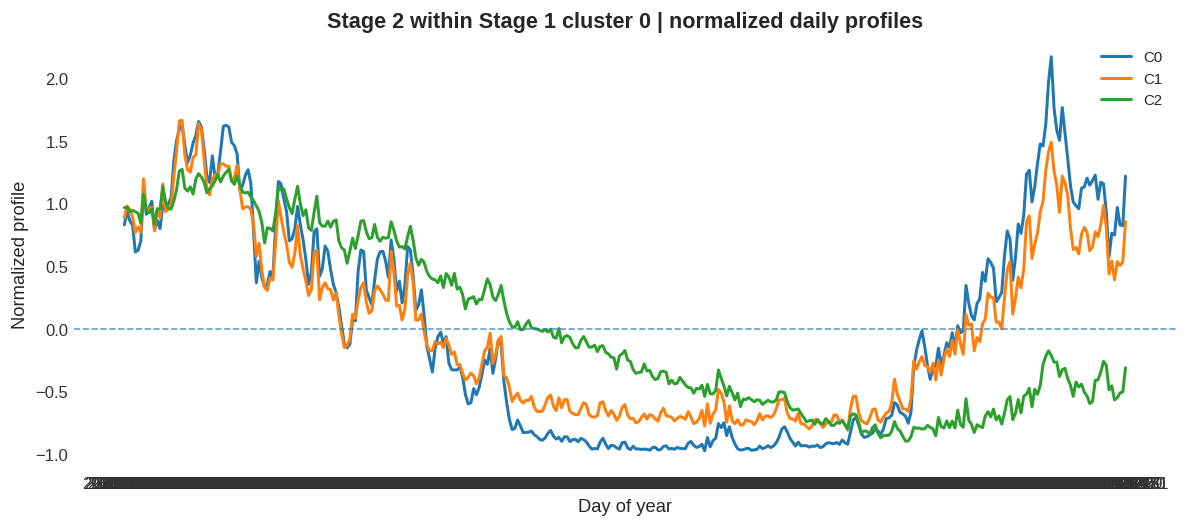


Stage 2 within Stage 1 cluster 1 | selected k = 3

Cluster sizes:


,cluster,n_households
0,0,1967
1,1,4130
2,2,256



Monthly profile by Stage 2 cluster:


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
cluster,,,,,,,,,,,,
0,8.859879,8.447557,7.900751,8.357057,9.295201,10.657485,11.708416,11.988654,11.026486,10.235708,11.681883,13.076856
1,10.503599,10.136006,9.073275,8.768588,7.743403,7.146782,7.023006,7.151113,6.995770,7.876827,9.502844,10.801758
2,24.732009,24.966454,23.458561,20.589533,19.389899,18.778151,18.856777,18.745739,18.801076,19.696240,23.620698,22.556908



Normalized mean daily profile by Stage 2 cluster:


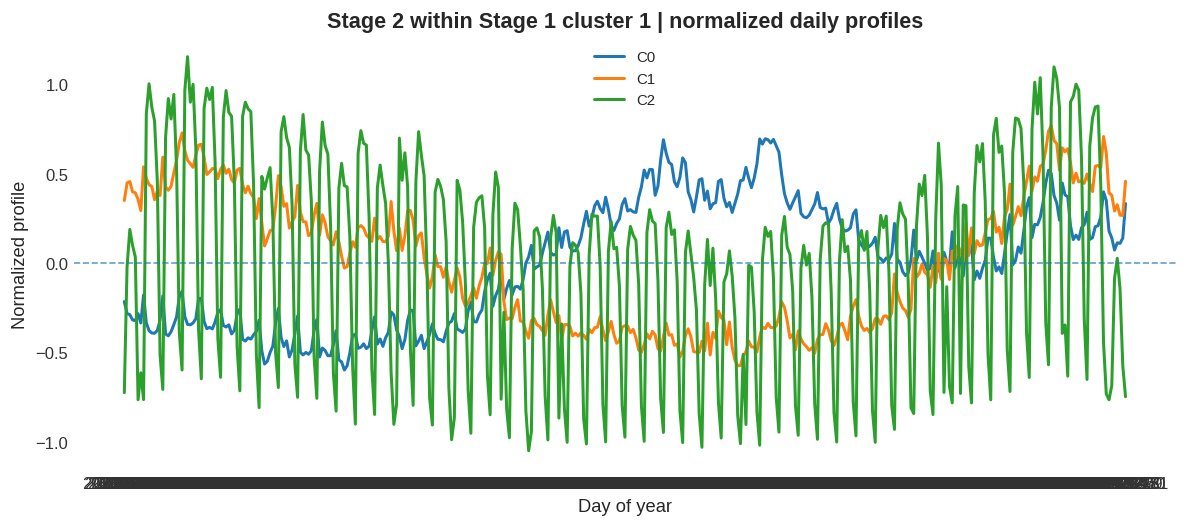


Stage 2 within Stage 1 cluster 2 | selected k = 2

Cluster sizes:


,cluster,n_households
0,0,2446
1,1,5238



Monthly profile by Stage 2 cluster:


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
cluster,,,,,,,,,,,,
0,8.132577,8.017844,7.710241,7.779759,7.290991,7.033829,6.999118,7.012362,6.960137,7.389860,7.866766,8.389409
1,6.948794,6.849814,6.555636,6.547389,6.345718,6.280401,6.371832,6.470717,6.337619,6.576231,6.994904,7.339288



Normalized mean daily profile by Stage 2 cluster:


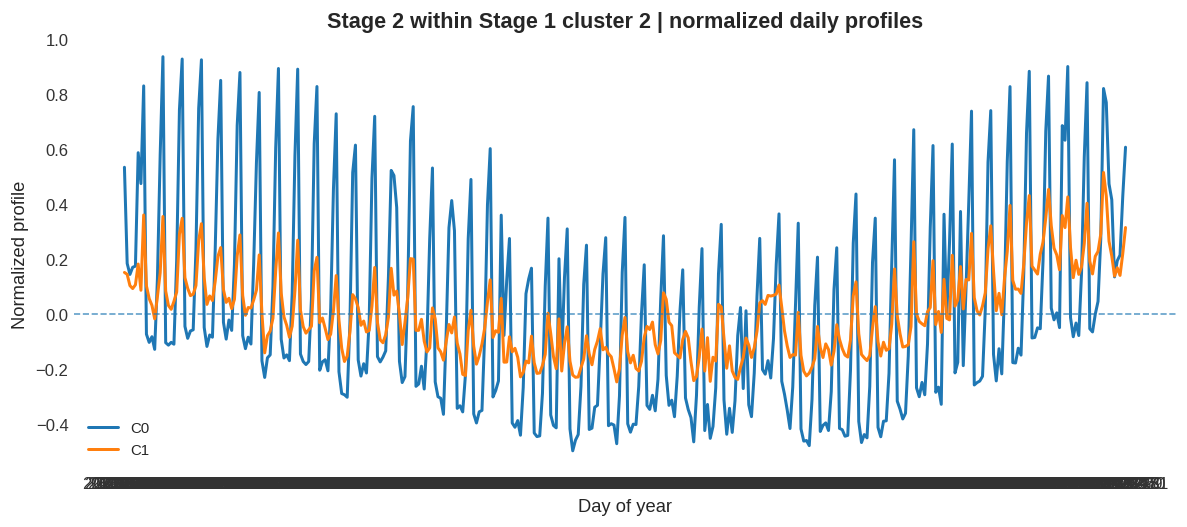

In [34]:
for parent_cluster, selected in stage2_selected.items():
    labels_sub = selected["labels"]
    k = selected["k"]

    print(f"\n{'='*80}")
    print(f"Stage 2 within Stage 1 cluster {parent_cluster} | selected k = {k}")
    print(f"{'='*80}")

    print("\nCluster sizes:")
    display(labels_sub.value_counts().sort_index().rename_axis("cluster").reset_index(name="n_households"))

    print("\nMonthly profile by Stage 2 cluster:")
    display(reporter.mean_monthly_profile_by_cluster(train_data.loc[labels_sub.index], labels_sub))

    print("\nNormalized mean daily profile by Stage 2 cluster:")
    norm_profiles = reporter.mean_normalized_profile_by_cluster(train_data.loc[labels_sub.index], labels_sub)

    plt.figure(figsize=(10, 4.5))
    for cluster_id in norm_profiles.index:
        plt.plot(norm_profiles.columns, norm_profiles.loc[cluster_id], label=f"C{cluster_id}", linewidth=1.8)
    plt.axhline(0, linestyle="--", linewidth=1.0, alpha=0.7)
    plt.title(f"Stage 2 within Stage 1 cluster {parent_cluster} | normalized daily profiles")
    plt.xlabel("Day of year")
    plt.ylabel("Normalized profile")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
for parent_cluster, selected in stage2_selected.items():
    labels_sub = selected["labels"]

    # subset the interpretable feature table to the households inside this parent cluster
    X_sub_features = stage2_feature_table.loc[labels_sub.index]

    stage2_top_features = compute_top_distinguishing_features(
        features=X_sub_features,
        labels=labels_sub,
        feature_blocks=stage2_feature_blocks,
        top_n=8,
    )

    print(f"\n{'='*80}")
    print(f"Stage 2 top distinguishing features: Stage 1 cluster {parent_cluster}")
    print(f"{'='*80}")

    for subcluster_id, table in stage2_top_features.items():
        print(f"\nParent cluster {parent_cluster} | Stage 2 subcluster {subcluster_id}")
        display(
            table[
                [
                    "cluster_mean",
                    "overall_mean",
                    "standardized_difference",
                    "feature_family",
                ]
            ]
        )


Stage 2 top distinguishing features: Stage 1 cluster 0

Parent cluster 0 | Stage 2 subcluster 0


,cluster_mean,overall_mean,standardized_difference,feature_family
autocorr_lag_7,0.788793,0.731705,0.488618,weekly
norm_monthly_profile_std,0.906597,0.868993,0.482660,shape_normalized
norm_winter_summer_diff,2.049237,1.821865,0.474854,shape_normalized
autocorr_lag_30,0.572767,0.510029,0.434998,persistence
norm_month_Nov,0.574649,0.369741,0.417520,shape_normalized
norm_month_Dec,1.227971,0.963562,0.414068,shape_normalized
norm_month_Jun,-0.900365,-0.750185,-0.397330,shape_normalized
norm_month_Jul,-0.947587,-0.821984,-0.387183,shape_normalized



Parent cluster 0 | Stage 2 subcluster 1


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_monthly_profile_std,0.790909,0.868993,-1.002237,shape_normalized
autocorr_lag_7,0.615026,0.731705,-0.998661,weekly
autocorr_lag_30,0.369490,0.510029,-0.974426,persistence
norm_dow_range,0.373549,0.266801,0.577466,shape_normalized
norm_month_entropy,2.303216,2.341375,-0.499375,shape_normalized
norm_month_Sep,-0.722753,-0.825323,0.406471,shape_normalized
norm_month_Aug,-0.677975,-0.796042,0.405485,shape_normalized
norm_winter_summer_diff,1.641365,1.821865,-0.376964,shape_normalized



Parent cluster 0 | Stage 2 subcluster 2


...

,cluster_mean,overall_mean,standardized_difference,feature_family
norm_weekend_weekday_diff,-1.056760,0.007728,-2.902849,shape_normalized
norm_dow_range,1.591190,0.555392,2.745588,shape_normalized
norm_dow_Sun,-0.855880,0.032112,-2.738661,shape_normalized
norm_dow_Sat,-0.649075,-0.021247,-2.289090,shape_normalized
norm_dow_Tue,0.467535,0.010166,2.203171,shape_normalized
norm_dow_Thu,0.345270,-0.019708,1.980823,shape_normalized
norm_dow_Wed,0.392099,0.001703,1.973517,shape_normalized
diff_std,11.078823,3.701861,1.688174,persistence



Stage 2 top distinguishing features: Stage 1 cluster 2

Parent cluster 2 | Stage 2 subcluster 0


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_weekend_weekday_diff,0.637540,0.290759,0.970831,shape_normalized
norm_dow_range,1.084947,0.735239,0.944640,shape_normalized
autocorr_lag_7,0.283325,0.171264,0.868901,weekly
norm_dow_Sun,0.558189,0.272874,0.834042,shape_normalized
norm_dow_Sat,0.349516,0.140996,0.712060,shape_normalized
norm_dow_Tue,-0.246118,-0.108378,-0.692853,shape_normalized
norm_dow_Wed,-0.229034,-0.107605,-0.612654,shape_normalized
norm_dow_Thu,-0.222350,-0.110779,-0.608949,shape_normalized



Parent cluster 2 | Stage 2 subcluster 1


,cluster_mean,overall_mean,standardized_difference,feature_family
norm_weekend_weekday_diff,0.128821,0.290759,-0.453351,shape_normalized
norm_dow_range,0.571936,0.735239,-0.441121,shape_normalized
autocorr_lag_7,0.118935,0.171264,-0.405753,weekly
norm_dow_Sun,0.139640,0.272874,-0.389474,shape_normalized
norm_dow_Sat,0.043623,0.140996,-0.332512,shape_normalized
norm_dow_Tue,-0.044057,-0.108378,0.323543,shape_normalized
norm_dow_Wed,-0.050901,-0.107605,0.286092,shape_normalized
norm_dow_Thu,-0.058678,-0.110779,0.284362,shape_normalized
